# Classification of player's position

## Imports

In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.multiclass import OneVsRestClassifier
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

## Load data

In [2]:
DATA_DIR = Path("data/13")

profiles_df = pd.read_csv(DATA_DIR / "all_player_profiles.csv")
stats_df = pd.read_csv(DATA_DIR / "all_player_stats.csv")

df = profiles_df.merge(stats_df, on=["player_id", "league"], how="inner", validate="one_to_one")
print(f"Profiles: {len(profiles_df)}, Stats: {len(stats_df)}, Merged: {len(df)}")
df.head()

Profiles: 4740, Stats: 3749, Merged: 3749


,player_id,name,league,position,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
0,804508,Viktor Gyökeres,Premier League,F,61000000.0,30,24,1997,12,0,10.3733,1.773005,6.573333,47,18,5,0,6,1,0
1,934235,Bukayo Saka,Premier League,F,126000000.0,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0
2,794839,Gabriel Jesus,Premier League,F,21000000.0,12,2,320,2,0,1.8434,0.247789,6.541667,15,10,2,0,4,2,0
3,922573,Gabriel Martinelli,Premier League,F,42000000.0,26,10,906,1,3,3.3793,0.999809,6.607692,25,10,2,0,10,0,0
4,836705,Kai Havertz,Premier League,F,48000000.0,7,4,318,0,1,1.2721,0.105223,6.557143,7,1,0,0,5,0,0


In [5]:
feature_columns = ['market_value', 'appearances', 'matches_started', 'minutes_played', 
                'goals', 'assists', 'expected_goals', 'expected_assists', 'rating',
                'total_shots', 'shots_on_target', 'yellow_cards', 'red_cards', 'tackles',
                'interceptions', 'saves']
X = df[feature_columns]

position_map = {'F': 0, 'M': 1, 'D': 2, 'G': 3}
y = df['position'].map(position_map)

## Preprocessing + training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
], memory=None)

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", OneVsRestClassifier(LogisticRegression(random_state=42)))
], memory=None)

model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Ca

## Predict

In [18]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_proba = model.predict_proba(X_train)
test_proba = model.predict_proba(X_test)

metrics = pd.DataFrame({
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, train_pred),
        accuracy_score(y_test, test_pred)
    ],
    "roc_auc": [
        roc_auc_score(y_train, train_proba, multi_class='ovr'),
        roc_auc_score(y_test, test_proba, multi_class='ovr')
    ]
})

metrics

,split,accuracy,roc_auc
0,train,0.698233,0.903657
1,test,0.678667,0.899755


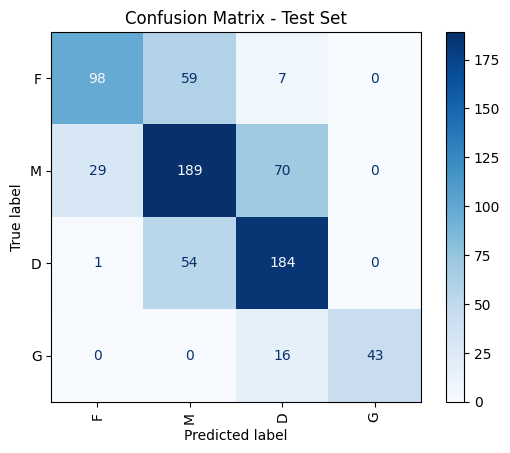

In [16]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'D', 'G'])
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.show()

## Model conparison

In [29]:
models = [LogisticRegression, SVC, KNeighborsClassifier,
           DecisionTreeClassifier, RandomForestClassifier]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
], memory=None)

results = []

for model in models:
    if model == KNeighborsClassifier:
        classifier = Pipeline([
            ("preprocess", preprocessor),
            ("model", OneVsRestClassifier(model()))
        ], memory=None)
    elif model == SVC:
        classifier = Pipeline([
            ("preprocess", preprocessor),
            ("model", OneVsRestClassifier(model(probability=True, random_state=42)))
        ], memory=None)
    else:
        classifier = Pipeline([
            ("preprocess", preprocessor),
            ("model", OneVsRestClassifier(model(random_state=42)))
        ], memory=None)

    classifier.fit(X_train, y_train)

    # Make predictions
    train_pred = classifier.predict(X_train)
    test_pred = classifier.predict(X_test)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    test_precision = precision_score(y_test, test_pred, average='macro')
    test_recall = recall_score(y_test, test_pred, average='macro')


    results.append({
        'model': model.__name__,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'precision': test_precision,
        'recall': test_recall
    })

# Display results
results_df = pd.DataFrame(results)
results_df

,model,train_accuracy,test_accuracy,precision,recall
0,LogisticRegression,0.698233,0.678667,0.763912,0.680859
1,SVC,0.728243,0.724000,0.771544,0.774750
2,KNeighborsClassifier,0.777259,0.652000,0.720074,0.702694
3,DecisionTreeClassifier,1.000000,0.562667,0.664784,0.660874
4,RandomForestClassifier,1.000000,0.705333,0.774208,0.750529
